# Load Dataset

In [1]:
# data
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore") 

# visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# model
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import dendrogram, ward
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import AffinityPropagation
from sklearn.cluster import MeanShift, estimate_bandwidth

# grid search
from sklearn.model_selection import GridSearchCV

# evaluation
from sklearn.metrics.cluster import silhouette_score
from sklearn.model_selection import cross_val_score
from sklearn import metrics
from sklearn.metrics import *

In [2]:
df = pd.read_csv('data/정제데이터/동별데이터_스케일링.csv', encoding='cp949')

# 환경불평등지수
- 기초수급자_인구밀도 + (1-인당녹지면적)

In [3]:
df['환경불평등지수'] = df.기초수급자_인구밀도 + (1- df.인당녹지면적)

In [4]:
df.head(3)

,시군구,행정동,기초수급자_인구밀도,저소득층_비율,총생활인구,초미세먼지,미세먼지,인당녹지면적,총공시지가평균,평균기온(°C),환경불평등지수
0,강북구,미아동,0.191522,0.335542,0.336260,0.0,0.6,0.283271,0.410610,0.767123,0.908251
1,강북구,번1동,0.260409,0.280052,0.238526,0.0,0.6,0.688506,0.290138,0.767123,0.571903
2,강북구,번2동,0.279518,0.192972,0.149009,0.0,0.6,0.702847,0.295058,0.767123,0.576671


In [5]:
data = df[['총생활인구','환경불평등지수']]

# Modeling

## from sklearn.cluster import AgglomerativeClustering 
hc = AgglomerativeClustering(n_clusters = 5, affinity = 'euclidean', linkage ='ward')Hierarchical agglomerative clustering

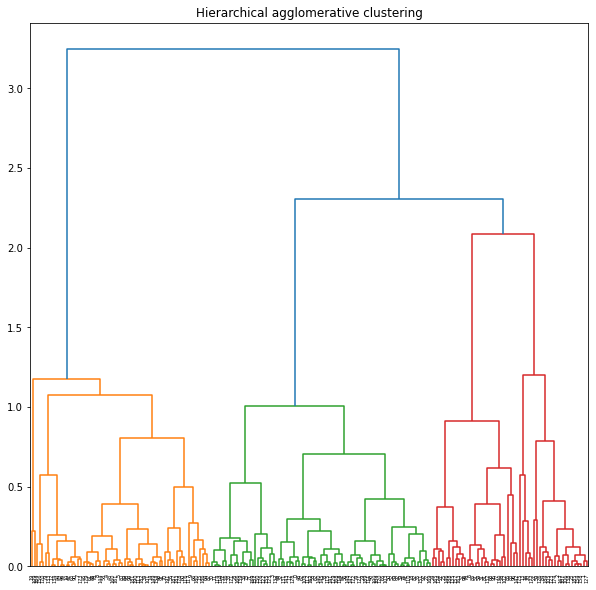

In [6]:
import scipy.cluster.hierarchy as shc

plt.figure(figsize=(10, 10))
plt.title("Hierarchical agglomerative clustering")
dend = shc.dendrogram(shc.linkage(data, method='ward'))

In [7]:
from sklearn.cluster import AgglomerativeClustering 
k=5
hc = AgglomerativeClustering(n_clusters = k, affinity = 'euclidean', linkage ='ward')
# 클러스터링 결과 각 데이터가 몇 번째 그룹에 속하는지 저장
df['cluster'] = hc.fit_predict(data)

Gulim


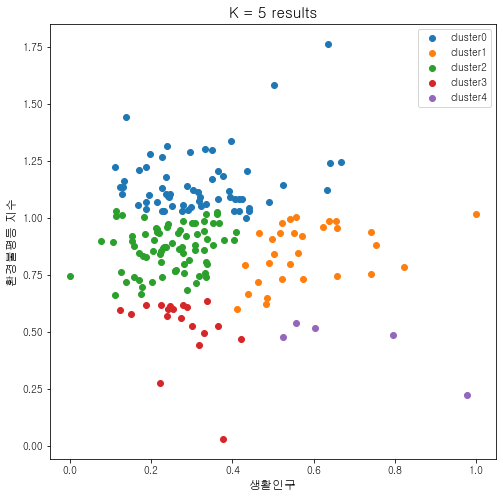

In [8]:
import matplotlib.pyplot as plt

# 한글폰트설정
font_name = 'Gulim'
print(font_name)
plt.rc('font', family=font_name)

plt.figure(figsize = (8, 8))

for i in range(k):
    plt.scatter(df.loc[df['cluster'] == i, '총생활인구'], df.loc[df['cluster'] == i, '환경불평등지수'], label = 'cluster' + str(i))

plt.legend()
plt.title('K = %d results'%k , size = 15)
plt.xlabel('생활인구', size = 12)
plt.ylabel('환경불평등 지수', size = 12)
plt.show()

In [9]:
cluster_cnt = df.groupby('cluster').agg({'행정동':'count'}).reset_index()
cluster_des = df.groupby('cluster').mean().reset_index()

In [11]:
a = pd.merge(cluster_cnt,cluster_des)

In [12]:
import dataframe_image as dfi

dfi.export(a, './image/17-1구별_hierarchic_describe.png', max_cols = -1, max_rows = -1)

In [15]:
df[df.cluster==0].행정동.unique()

array(['삼각산동', '삼양동', '송천동', '수유1동', '수유2동', '수유3동', '인수동', '가양2동',
       '가양3동', '등촌3동', '난곡동', '성현동', '신림동', '신사동', '신원동', '은천동', '구의1동',
       '구의3동', '군자동', '자양1동', '자양2동', '자양4동', '중곡1동', '중곡3동', '개봉1동',
       '구로4동', '구로5동', '수궁동', '독산2동', '독산3동', '독산4동', '시흥1동', '시흥2동',
       '시흥4동', '시흥5동', '상계2동', '상계5동', '중계2·3동', '하계2동', '방학1동', '방학2동',
       '장안1동', '장안2동', '목3동', '신월3동', '신월7동', '신정3동', '갈현1동', '갈현2동',
       '대조동', '역촌동', '응암3동', '면목2동', '면목3·8동', '면목4동', '면목5동', '면목7동',
       '면목본동', '상봉1동', '상봉2동', '중화1동', '중화2동'], dtype=object)